In [2]:
from tripodpy import Simulation
import numpy as np 
import csv
import matplotlib.pyplot as plt
import dustpy.constants as c

In [107]:
sim = Simulation()

In [108]:
sim.initialize()

In [109]:
list_t = []
list_ts = []
def updater_t(sim):
    list_t.append(sim.t)
    list_ts.append(sim.t.prevstepsize)

sim.star.M.updater = updater_t

In [110]:

dir(sim.t)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__annotate_func__',
 '__annotations_cache__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lsh

In [111]:

with open("test_sim.csv", "w", newline="") as f:
    writer = csv.writer(f)


    for row in zip(sim.grid.r,sim.grid.OmegaK,sim.gas.Sigma,sim.gas.cs,sim.gas.Hp,sim.gas.T,sim.gas.mu,sim.gas.mfp,sim.gas.eta,sim.gas.P):
        writer.writerow(row)

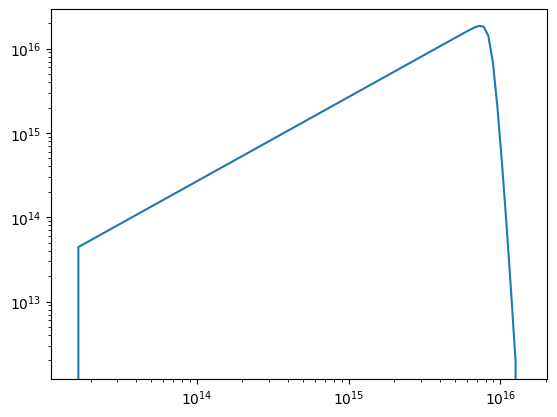

In [112]:
plt.figure()
plt.loglog(sim.grid.r,sim.dust.D[:,2])

In [113]:
sim.dust.D[:4,2]

[0.00000000e+00 4.42816271e+13 4.74486183e+13 5.08421105e+13]

In [114]:
sim.t.snapshots = [36937.52348959519*c.year]#,1e5*c.year]
sim.t.snapshots = [1e5*c.year]
sim.gas.nu = 0e0 
sim.gas.nu.updater = None

In [115]:
sim.writer.overwrite = True
sim.run()


tripodpy v1.0.0

Writing file data/data0000.hdf5
Writing dump file data/frame.dmp
Execution time: 0:00:09


In [116]:
sim.t/c.year

100000.0

In [117]:
sim.grid.ri[-1]/c.au

np.float64(999.999999999997)

In [135]:
import pandas as pd

df = pd.read_csv("tri_0080.outputdat", sep=r"\s+", header=None)

df2 = pd.read_csv("tri_0093.outputdat", sep=r"\s+", header=None)

In [136]:
df2[6][0]/c.year

np.float64(100020.8386779735)

In [137]:
sim.t/c.year

100000.0

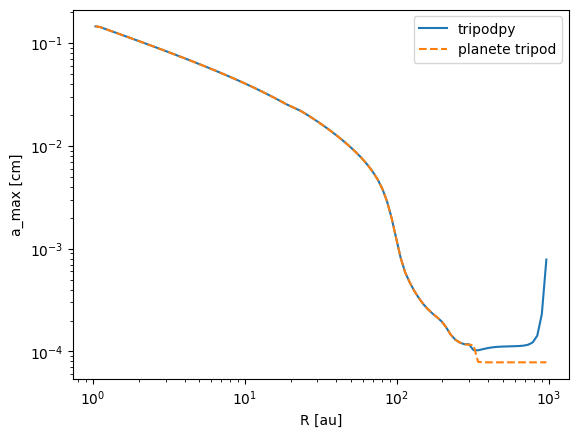

In [138]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.s.max,label="tripodpy")
#plt.loglog(df[1]/c.au,df[4],"--")
plt.loglog(df2[1]/c.au,df2[4],"--",label="planete tripod")
plt.ylabel("a_max [cm]")
plt.xlabel("R [au]")
plt.legend()

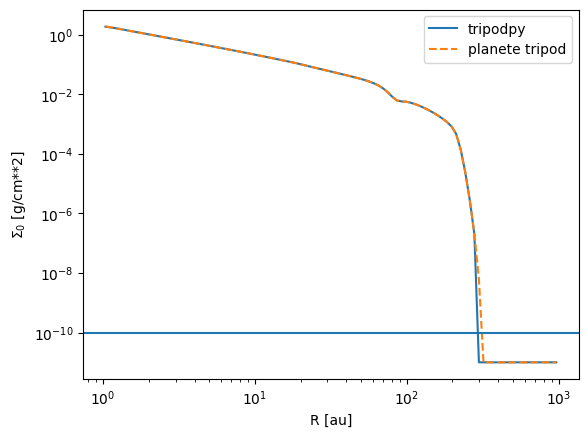

In [139]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,0],label="tripodpy")
plt.loglog(df2[1]/c.au,df2[2],"--",label = "planete tripod")
#plt.loglog(df2[1]/c.au,df[2],"x--")
plt.axhline(1e-10)
plt.ylabel(r"$\Sigma_0$ [g/cm**2]")
plt.xlabel("R [au]")
#plt.ylim(1e-4)
plt.legend()

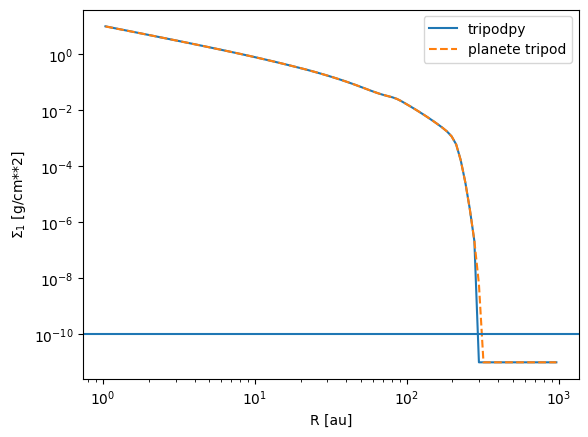

In [145]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,1],label="tripodpy")
plt.loglog(df2[1]/c.au,df2[3],"--",label = "planete tripod")
#plt.loglog(df2[1]/c.au,df2[2],"--",label = "planete tripod")
plt.axhline(1e-10)
plt.ylabel(r"$\Sigma_1$ [g/cm**2]")
plt.xlabel("R [au]")
#plt.ylim(1e-4)
plt.legend()


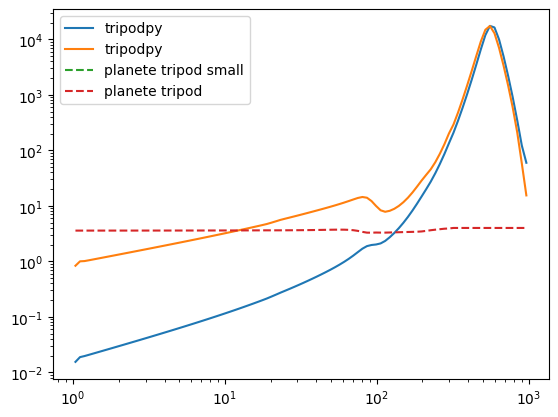

In [141]:
plt.figure()
plt.plot(sim.grid.r/c.au,-sim.dust.v.rad[:,0],label="tripodpy")
plt.plot(sim.grid.r/c.au,-sim.dust.v.rad[:,2],label="tripodpy")
plt.plot(df2[1]/c.au,-df2[4],"--",label = "planete tripod small")
plt.plot(df2[1]/c.au,-df2[5],"--",label = "planete tripod")
#plt.axhline(1)
plt.xscale("log")
#plt.ylim(1e-4,1e2)
plt.yscale("log")
plt.legend()

(1, 500)

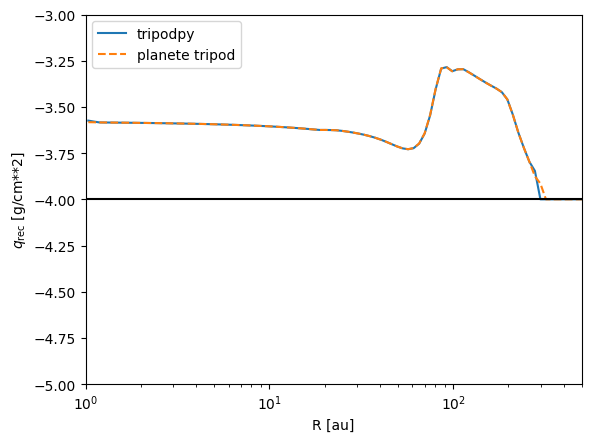

In [142]:
plt.figure()
plt.plot(sim.grid.r/c.au,sim.dust.qrec[:],label="tripodpy")
plt.plot(df2[1]/c.au,df2[5],"--",label = "planete tripod")
#plt.plot(df2[1]/c.au,df[5],"--",label = "planete tripod")
plt.ylabel(r"$q_{\rm rec}$ [g/cm**2]")
plt.xlabel("R [au]")
plt.legend()
plt.ylim(-5,-3)
plt.xscale("log")
plt.axhline(-4,color="k")
plt.xlim(1,500)

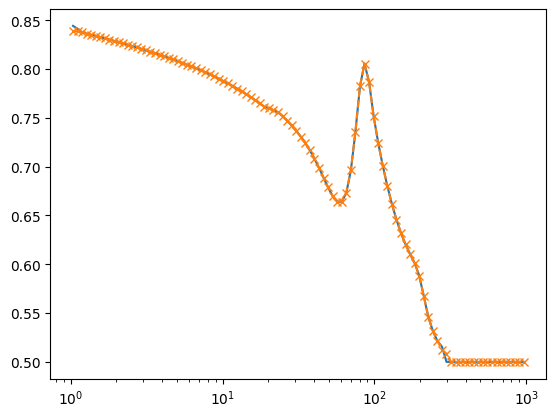

In [144]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,1]/sim.dust.Sigma.sum(-1))
plt.loglog(df2[1]/c.au,df2[3]/(df2[3]+df2[2]),"x--")
#plt.loglog(df2[1]/c.au,df[3]/(df[3]+df[2]),"x--")
plt.yscale("linear")
#plt.loglog(df2[1]/c.au,df[2],"x--")

In [127]:
df[6][0]/c.year

np.float64(36937.52348959519)

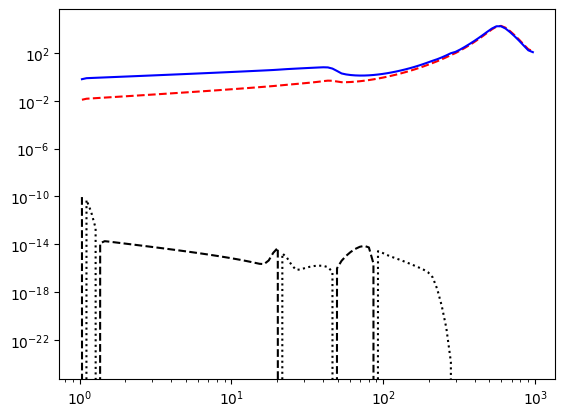

In [128]:
plt.figure()
#plt.plot(sim.grid.r/c.au,sim.dust.s.sdot_coag[:],"-+")

plt.plot(df2[1]/c.au,-df[4],"r--")
plt.plot(df2[1]/c.au,-df[5],"b")
plt.plot(sim.grid.r/c.au,sim.dust.S.coag[:,1],"k:")
plt.plot(sim.grid.r/c.au,sim.dust.S.coag[:,0],"k--")
plt.xscale("log")
plt.yscale("log")
#plt.ylim(1e-4,1e0)

In [129]:
sim.dust.S.toc

Group (Sources)
    - coag: Field (Coagulation sources [g/cm²/s])
    - compo: Field (Sources due to composition changes [g/cm²/s])
    - ext: Field (External sources [g/cm²/s])
    - hyd: Field (Hydrodynamic sources [g/cm²/s])
    - smax_hyd: Field (Total sources [g/cm²/s])
    - tot: Field (Total sources [g/cm²/s])


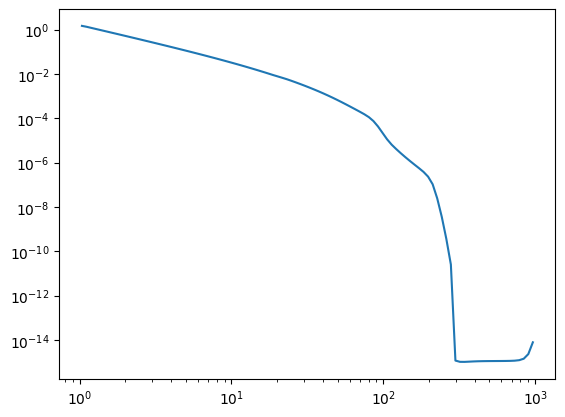

In [130]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.s.max*sim.dust.Sigma[:,1])
#plt.loglog(df[1]/c.au,df[4],"--")
plt.loglog(df2[1]/c.au,df2[4]*df2[3],":")

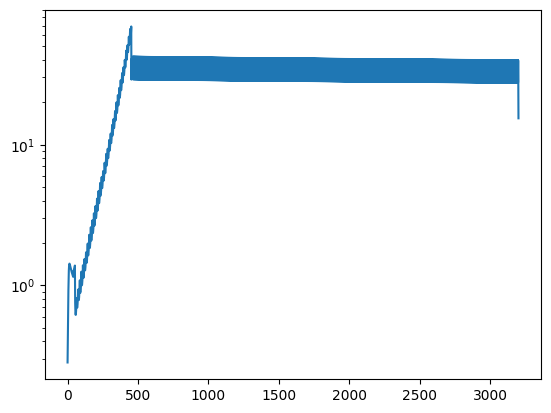

In [131]:
plt.figure()
plt.plot(np.array(list_ts)/c.year)
plt.yscale("log")

In [132]:
sim.dust.delta.rad

[0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001]

In [133]:
sim.dust.backreaction.A,
#sim.dust.backreaction.B

([1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1.],)

In [134]:
sim.dust.v.driftmax

[-3.23513388e+03 -3.72027878e+03 -3.72980354e+03 -3.73172851e+03
 -3.73379119e+03 -3.73600142e+03 -3.73836977e+03 -3.74090756e+03
 -3.74362690e+03 -3.74654079e+03 -3.74966316e+03 -3.75300892e+03
 -3.75659406e+03 -3.76043573e+03 -3.76455228e+03 -3.76896339e+03
 -3.77369015e+03 -3.77875517e+03 -3.78418266e+03 -3.78999858e+03
 -3.79623075e+03 -3.80290899e+03 -3.81006525e+03 -3.81773378e+03
 -3.82595128e+03 -3.83475710e+03 -3.84419341e+03 -3.85430540e+03
 -3.86514152e+03 -3.87675370e+03 -3.88919760e+03 -3.90253291e+03
 -3.91682358e+03 -3.93213819e+03 -3.94855027e+03 -3.96613865e+03
 -3.98498782e+03 -4.00518843e+03 -4.02683763e+03 -4.05003964e+03
 -4.07490620e+03 -4.10155717e+03 -4.13012111e+03 -4.16073593e+03
 -4.19354956e+03 -4.22872074e+03 -4.26641979e+03 -4.30682950e+03
 -4.35014606e+03 -4.39658008e+03 -4.44635768e+03 -4.49972170e+03
 -4.55693297e+03 -4.61827172e+03 -4.68403907e+03 -4.75455874e+03
 -4.83017880e+03 -4.91127364e+03 -4.99824616e+03 -5.09153008e+03
 -5.19159254e+03 -5.29893

In [3]:
sim = Simulation()

In [4]:
sim.initialize()

In [11]:
sim.components.Default.gas.S.ext.updater

Heartbeat
---------

Systole:  None
Updater:  <function addcomponent.<locals>.<lambda> at 0x11d0dc9e0>
Diastole: None

Docstrings
----------

Systole:
The type of the None singleton.

Updater:
None

Diastole:
The type of the None singleton.